In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
from scipy import stats
from scipy.stats import gaussian_kde, t
from scipy.stats import linregress, ks_2samp

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates



import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

import warnings
warnings.filterwarnings('ignore')

from plot_utils import *

In [2]:
def compute_state_precip_r2(df, crash_col='ANOM_CRASH_COUNTS', precip_col='PRECIP_ANOM_MEAN', significance_level=0.05):
    """
    Compute linear regression statistics (R², slope, p-value, significance) 
    between crash anomalies and precipitation anomalies for each state.

    Parameters:
    - df: pandas DataFrame containing columns for state, crash anomalies, and precip anomalies
    - crash_col: str, column name of crash anomaly variable
    - precip_col: str, column name of precipitation anomaly variable
    - significance_level: float, p-value threshold for significance

    Returns:
    - r2_df: pandas DataFrame with columns: STATE_ABBR, R2, slope, p_value, significant
    """
    
    results = []

    for state, group in df.groupby('STATE_ABBR'):
        group = group.dropna(subset=[crash_col, precip_col])
        
        if len(group) > 1:
            slope, intercept, r_value, p_value, std_err = linregress(
                group[precip_col], group[crash_col]
            )
            significant = p_value < significance_level
            results.append({
                'STATE_ABBR': state,
                'R2': r_value**2,
                'p_value': p_value,
                'slope': slope,
                'significant': significant
            })
        else:
            results.append({
                'STATE_ABBR': state,
                'R2': None,
                'p_value': None,
                'slope': None,
                'significant': None
            })

    r2_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
    return r2_df


In [3]:
def compute_enso_avg_anomalies(df, variable, enso_col='NINO34_SST',
                               threshold_el=0.5, threshold_ln=-0.5):
    """
    Compute average anomalies for El Niño and La Niña given a DataFrame
    with a STATE column.

    Parameters:
    - df: input DataFrame
    - variable: str, name of the anomaly variable column (e.g., 'PRECIP_ANOM_MEAN')
    - enso_col: str, column name of ENSO index
    - threshold_el: float, El Niño threshold
    - threshold_ln: float, La Niña threshold
    - exclude_states: list or set of states to exclude

    Returns:
    - el_nino_df, la_nina_df: DataFrames with average anomalies by state
    """

    # Filter ENSO phases
    el_nino_data = df[df[enso_col] >= threshold_el]
    la_nina_data = df[df[enso_col] <= threshold_ln]

    # Compute state-level averages for each ENSO phase
    el_nino_df = (
        el_nino_data
        .groupby("STATE_ABBR")[variable]
        .mean()
        .reset_index(name="Avg_Anomaly")
        .sort_values("Avg_Anomaly")
    )

    la_nina_df = (
        la_nina_data
        .groupby("STATE_ABBR")[variable]
        .mean()
        .reset_index(name="Avg_Anomaly")
        .sort_values("Avg_Anomaly")
    )

    return el_nino_df, la_nina_df

In [4]:
def read_vmt_trips_by_state(fname):
    """
    Clean the 'Vehicle miles traveled and vehicle trips by State' CSV:
    - remove first 3 rows and last row
    - clean column names
    - convert to numeric
    - convert state names → 2-letter abbreviations
    - drop excluded states (DC, AK, HI, PR)
    - compute Total_VMT
    """
    # Column names for cleaned DataFrame
    colnames = [
        "State",
        "VMT_Urban", "VMT_Suburban", "VMT_Rural",
        "Trips_Urban", "Trips_Suburban", "Trips_Rural"
    ]

    # Read raw file
    df = pd.read_csv(fname, header=None, dtype=str)

    # Remove first 3 rows and last row
    df = df.iloc[5:-1].reset_index(drop=True)

    # Keep only expected first 7 columns
    df = df.iloc[:, :7]

    # Remove any leftover header-like row (if "State" or similar appears again)
    first_cell = str(df.iat[0, 0]).strip().lower()
    if first_cell in {"state", "vehicle miles traveled and vehicle trips by state"} or first_cell.startswith("state"):
        df = df.iloc[1:].reset_index(drop=True)

    # Assign proper column names
    df.columns = colnames

    # Strip whitespace
    df["State"] = df["State"].str.strip()

    # Replace NA-like tokens
    df = df.replace({"N/A": pd.NA, "": pd.NA})

    # Convert numeric columns
    numeric_cols = colnames[1:]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # -------------------------------------------------------
    # Convert full state names → abbreviations
    # -------------------------------------------------------
    state_to_abbrev = {
        "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
        "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
        "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
        "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
        "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
        "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
        "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
        "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
        "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
        "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
        "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
        "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
        "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
        "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
        "Puerto Rico": "PR"
    }

    df["STATE_ABBR"] = df["State"].map(state_to_abbrev)

    # -------------------------------------------------------
    # Drop excluded states
    # -------------------------------------------------------
    excluded_states = {"DC", "AK", "HI", "PR"}
    df = df[~df["State"].isin(excluded_states)]

    # -------------------------------------------------------
    # Compute Total_VMT
    # -------------------------------------------------------
    df["Total_VMT"] = df[["VMT_Urban", "VMT_Suburban", "VMT_Rural"]].sum(axis=1)

    df = df.reset_index(drop=True)
    return df

In [5]:
state_centers = {
    'AL': (-86.8, 32.8), 'AZ': (-111.7, 34.3), 'AR': (-92.4, 34.9),
    'CA': (-119.7, 36.1), 'CO': (-105.5, 39.0), 'CT': (-72.7, 41.6),
    'DE': (-75.4, 38.1), 'FL': (-81.4, 28.6), 'GA': (-83.4, 32.6),
    'ID': (-114.6, 44.4), 'IL': (-89.2, 40.0), 'IN': (-86.3, 39.9),
    'IA': (-93.5, 42.1), 'KS': (-98.4, 38.5), 'KY': (-85.3, 37.5),
    'LA': (-92.0, 31.1), 'ME': (-69.2, 45.4), 'MD': (-76.8, 39.1),
    'MA': (-69.8, 42.3), 'MI': (-84.5, 43.3), 'MN': (-94.5, 46.0),
    'MS': (-89.7, 32.7), 'MO': (-92.5, 38.4), 'MT': (-109.5, 47.0),
    'NE': (-98.3, 41.1), 'NV': (-117.1, 38.3), 'NH': (-71.1, 45),
    'NJ': (-74.7, 40.2), 'NM': (-106.2, 34.8), 'NY': (-75.5, 43.0),
    'NC': (-79.4, 35.6), 'ND': (-100.5, 47.5), 'OH': (-82.8, 40.3),
    'OK': (-97.5, 35.6), 'OR': (-120.5, 44.1), 'PA': (-77.8, 40.9),
    'RI': (-71.5, 40.2), 'SC': (-80.9, 33.9), 'SD': (-100.2, 44.4),
    'TN': (-86.4, 35.9), 'TX': (-100.1, 31.2), 'UT': (-111.7, 39.3),
    'VT': (-72.6, 44.1), 'VA': (-78.2, 37.8), 'WA': (-121.6, 47.4),
    'WV': (-80.6, 38.6), 'WI': (-90.0, 44.6), 'WY': (-107.6, 43.0)
}

In [6]:
months_list=[12,1,2]
#months_list=[1,2,3,4,5,6,7,8,9,10,11,12]

# Read in datasets

In [7]:
df_daily_national=pd.read_csv('../data/combined_databases/database_daily_summary_national.csv',index_col=0,parse_dates=["DATE"])
df_daily_state=pd.read_csv('../data/combined_databases/database_daily_summary_state.csv',index_col=0,parse_dates=["DATE"])
df_monthly_national=pd.read_csv('../data/combined_databases/database_monthly_summary_national.csv',index_col=0,parse_dates=["DATE"])
df_monthly_state=pd.read_csv('../data/combined_databases/database_monthly_summary_state.csv',index_col=0,parse_dates=["DATE"])
ds_comp = xr.open_dataset('../data/wxregimes/era5_cluster_comp_z_na_DJF1981-2019.nc')
ds_precip_clim= xr.open_dataset('../data/wxregimes/era5_cluster_comp_z_na_DJF1981-2019.nc')

# FHWA state VMT: average annual VMT in millions of miles, 2008-2023 (FHWA Table VM-2)
df_fhwa_vmt = pd.read_csv('../data/fhwa_state_vmt_avg_2008_2023.csv')

In [8]:
total = len(df_daily_national)
missing = df_daily_national['FATAL_CRASH_COUNT'].isna().sum()
zeros = (df_daily_national['FATAL_CRASH_COUNT'] == 0).sum()

print(f"Total rows: {total}")
print(f"Missing: {missing} ({missing/total:.1%})")
print(f"Zeros: {zeros} ({zeros/total:.1%})")


Total rows: 15705
Missing: 0 (0.0%)
Zeros: 368 (2.3%)


In [9]:
# 1a. types and sample
print(df_daily_national['DATE'].dtype)
print(df_daily_national['FATAL_CRASH_COUNT'].dtype)
print(df_daily_national['DATE'].head(10))

# 1b. sorted?
print("Is DATE sorted:", df_daily_national['DATE'].is_monotonic_increasing)

# 1c. duplicates
dups = df_daily_national[df_daily_national.duplicated('DATE', keep=False)]
print("Duplicate DATE rows:", len(dups))
if len(dups):
    print(dups.head())

datetime64[ns]
float64
0   1981-01-01
1   1981-01-02
2   1981-01-03
3   1981-01-04
4   1981-01-05
5   1981-01-06
6   1981-01-07
7   1981-01-08
8   1981-01-09
9   1981-01-10
Name: DATE, dtype: datetime64[ns]
Is DATE sorted: True
Duplicate DATE rows: 0


In [10]:
monthly_counts = (
    df_daily_national
    .groupby([df_daily_national['DATE'].dt.year, df_daily_national['DATE'].dt.month])
    .size()
    .unstack(fill_value=0)
)
print(monthly_counts.head()) 

DATE  1   2   3   4   5   6   7   8   9   10  11  12
DATE                                                
1981  31  28  31  30  31  30  31  31  30  31  30  31
1982  31  28  31  30  31  30  31  31  30  31  30  31
1983  31  28  31  30  31  30  31  31  30  31  30  31
1984  31  29  31  30  31  30  31  31  30  31  30  31
1985  31  28  31  30  31  30  31  31  30  31  30  31


## Trend in crashes per year

In [11]:
# Ensure DATE is datetime
df = df_monthly_national.copy()
df['DATE'] = pd.to_datetime(df['DATE'])

# Take first and last points
y1 = df['FATAL_CRASH_ANOM_TREND'].iloc[0]
y2 = df['FATAL_CRASH_ANOM_TREND'].iloc[-1]

x1 = df['DATE'].iloc[0]
x2 = df['DATE'].iloc[-1]

# Compute slope: rise/run (crashes/day)
slope = (y2 - y1) / (x2 - x1).days

print('National trend (crashes/year): ',((y2-y1)/(x2-x1).days)*365)

National trend (crashes/year):  -5.317888515153655


## Average Crashes per Day

In [12]:
avg_crashes_per_day = df_monthly_national['FATAL_CRASH_COUNT'].mean()
print(f"Average crashes per day: {avg_crashes_per_day:.2f}")

Average crashes per day: 338.29


In [13]:
df_monthly_national

,DATE,FATAL_CRASH_COUNT,PRECIP_ANOM,NINO34_SST,NINO34_PRECIP_ANOM,CLUSTER_NAME,CLIM_CRASH,FATAL_CRASH_ANOM,FATAL_CRASH_ANOM_TREND,FATAL_CRASH_ANOM_DETREND
0,1981-01-01,335.0,-1.356085,-0.36,-0.036087,Greenland High,458.000000,-123.000000,114.181623,-237.181623
1,1981-02-01,474.0,0.486407,-0.64,-0.063302,Pacific Trough,385.581395,88.418605,102.743580,-14.324975
2,1981-03-01,361.0,-0.687008,-0.64,-0.063302,NaN,368.906977,-7.906977,113.322019,-121.228996
3,1981-04-01,364.0,-0.296151,-0.53,-0.052610,NaN,300.674419,63.325581,109.236433,-45.910851
4,1981-05-01,389.0,0.144107,-0.57,-0.056498,NaN,268.627907,120.372093,112.433276,7.938817
...,...,...,...,...,...,...,...,...,...,...
511,2023-08-01,158.0,0.015256,1.35,0.130122,NaN,227.744186,-69.744186,-112.404137,42.659951
512,2023-09-01,183.0,-0.152229,1.60,0.154421,NaN,259.232558,-76.232558,-109.208234,32.975676
513,2023-10-01,295.0,-0.573874,1.72,0.166085,NaN,351.116279,-56.116279,-113.292880,57.176601
514,2023-11-01,246.0,-0.945780,2.02,0.195245,NaN,440.697674,-194.697674,-110.068308,-84.629367


## Figure 5 Crashes & Climatology
a) Monthly fatal crash totals (orange) with annual cycle drawn in black
b) Monthly fatal crash anomalies (annual cycle removed), trend line shown in black

*Anomalies are relative to average number of crashes for a given state and month, then summed over all states for a national anomaly. Note this is different than taking the total number of crashes nationally and then calculating normal as the national average for a given month.  This is state-relative which is important for normalizing for state populations, driving habits, climatology, etc.

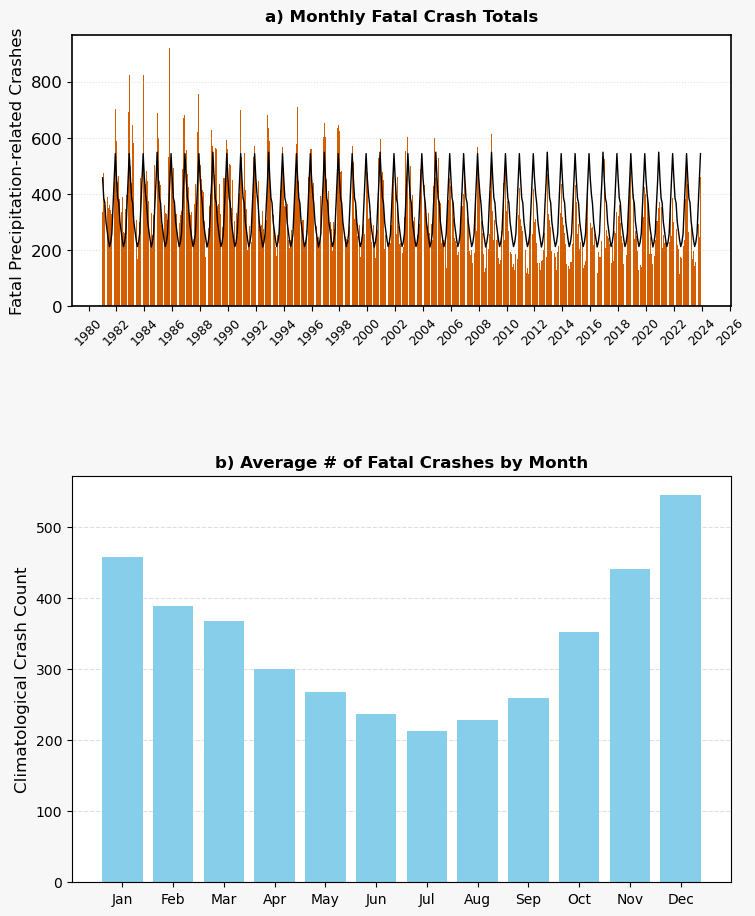

In [14]:
plot_crashes_clim(df_monthly_national,months_list,outname='../figs/Figure5.png')

## Figure 6
DJF state crash anomalies normalized by VMT

plot_monthly_and_djf_map(
    df_monthly_national,
    df_monthly_state,
    df_vehicle_miles,
    months_list,
    state_centers,
    save_path='../figs/Figure3.png',
    figsize=(12, 14)
)


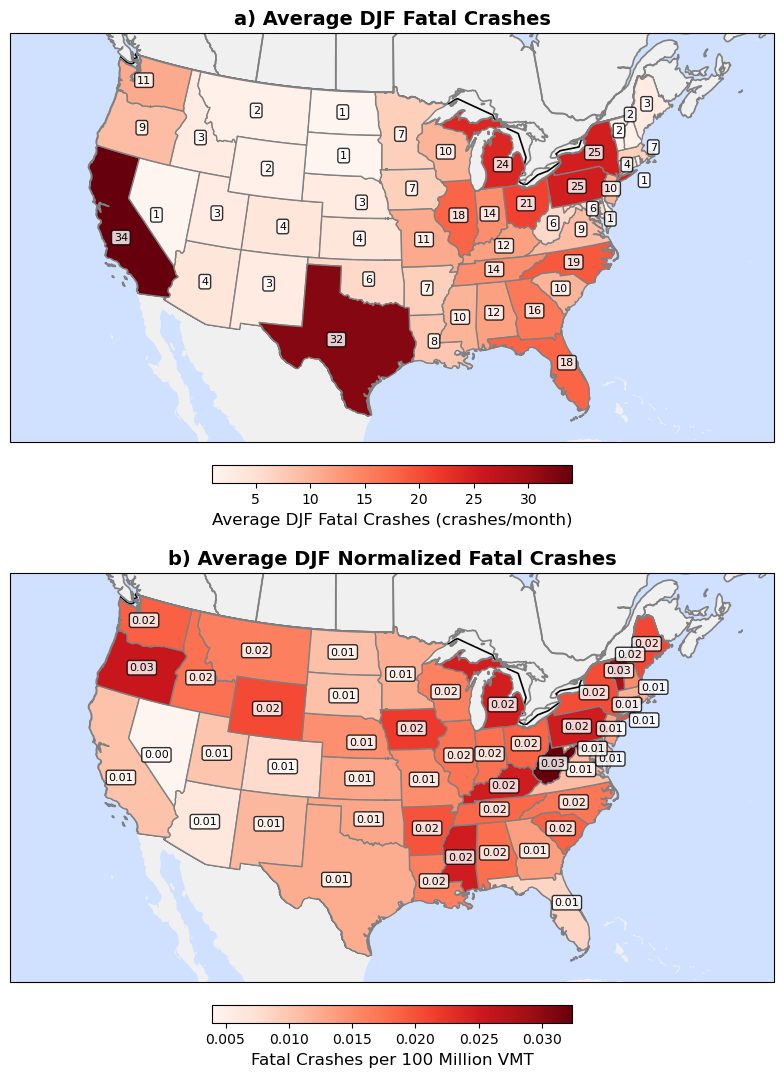

In [15]:
plot_djf_state_anomaly_maps(
    df_monthly_state,
    df_fhwa_vmt,
    months_list,
    state_centers,
    save_path='../figs/Figure6.png',
    figsize=(8.5, 11)
)

## Figure 7
Monthly fatal crash anomaly distributions

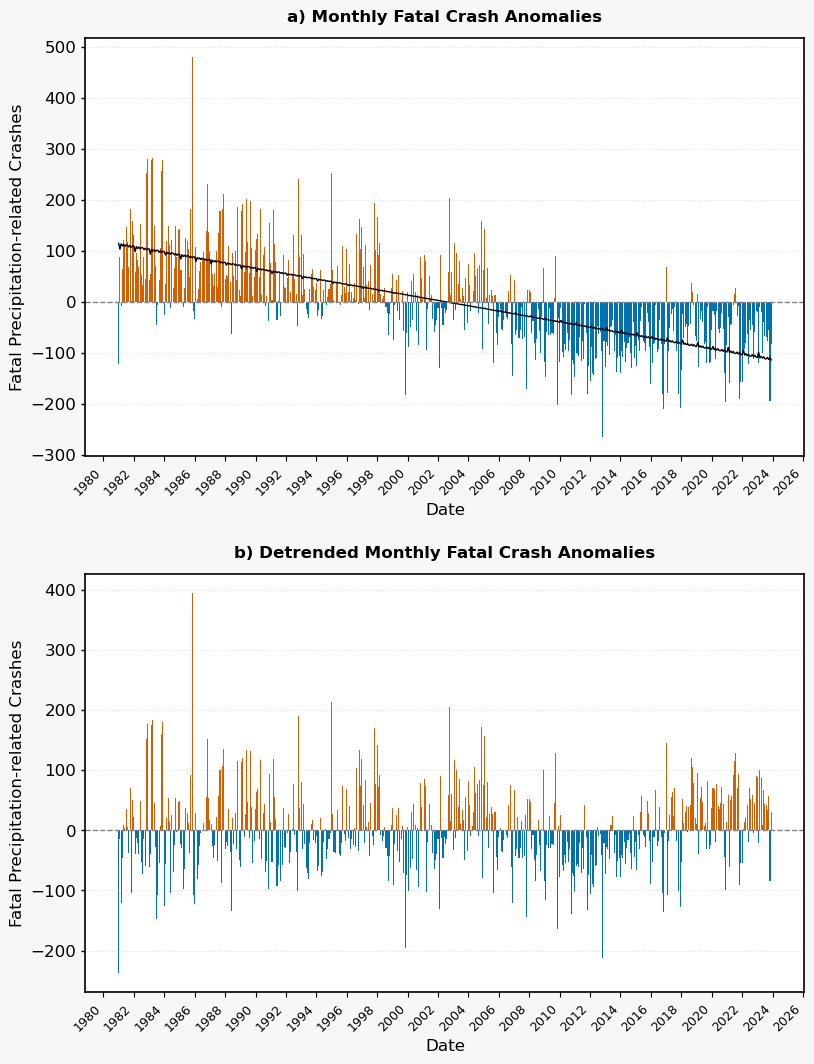

In [16]:
plot_crashes(df_monthly_national,save_path='../figs/Figure7.png')

## Figure 2
El Niño / La Niña state precipitation anomaly maps

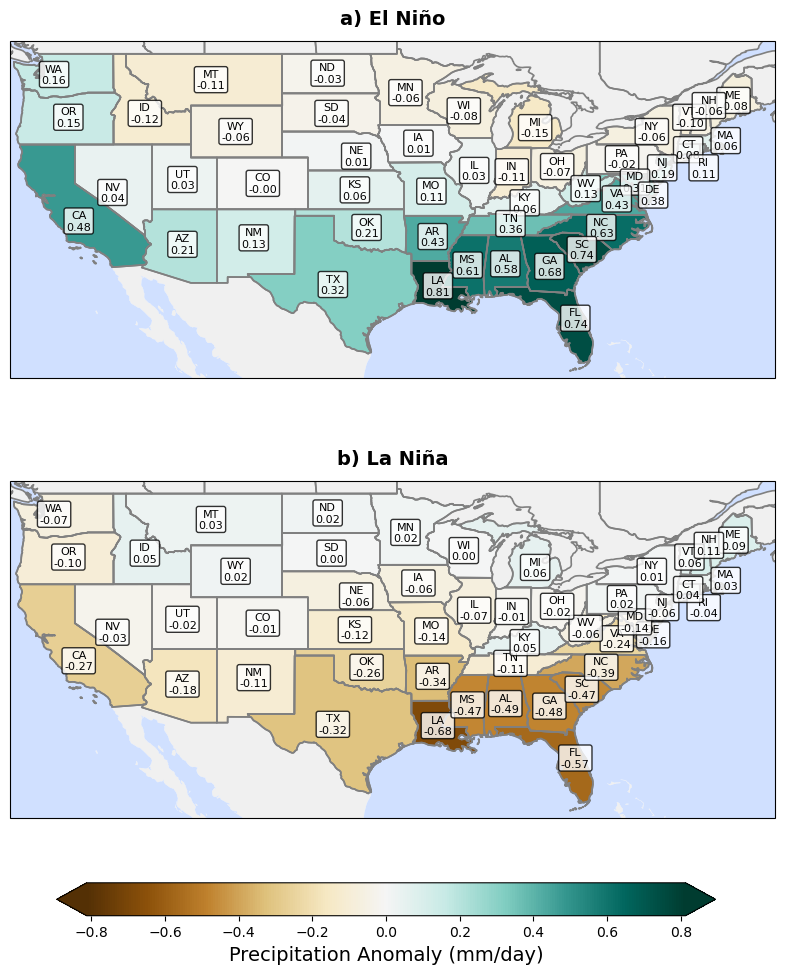

In [17]:
# Select DJF from Monthly State Data
df_djf = df_monthly_state[df_monthly_state['DATE'].dt.month.isin(months_list)]

# Compute El Niño and La Niña average precipitation anomalies
el_nino_avgs, la_nina_avgs = compute_enso_avg_anomalies(
    df_djf,
    variable='PRECIP_ANOM',
    enso_col='NINO34_SST'
)
# Convert DataFrames -> dicts
el_nino_dict = dict(zip(el_nino_avgs["STATE_ABBR"], el_nino_avgs["Avg_Anomaly"]))
la_nina_dict = dict(zip(la_nina_avgs["STATE_ABBR"], la_nina_avgs["Avg_Anomaly"]))

# Plot state-level anomaly maps for El Niño and La Niña
plot_enso_anomaly_maps(el_nino_dict, la_nina_dict, state_centers,save_path='../figs/Figure2.png')

## Figure 3
Weather regime 500 hPa geopotential height composites

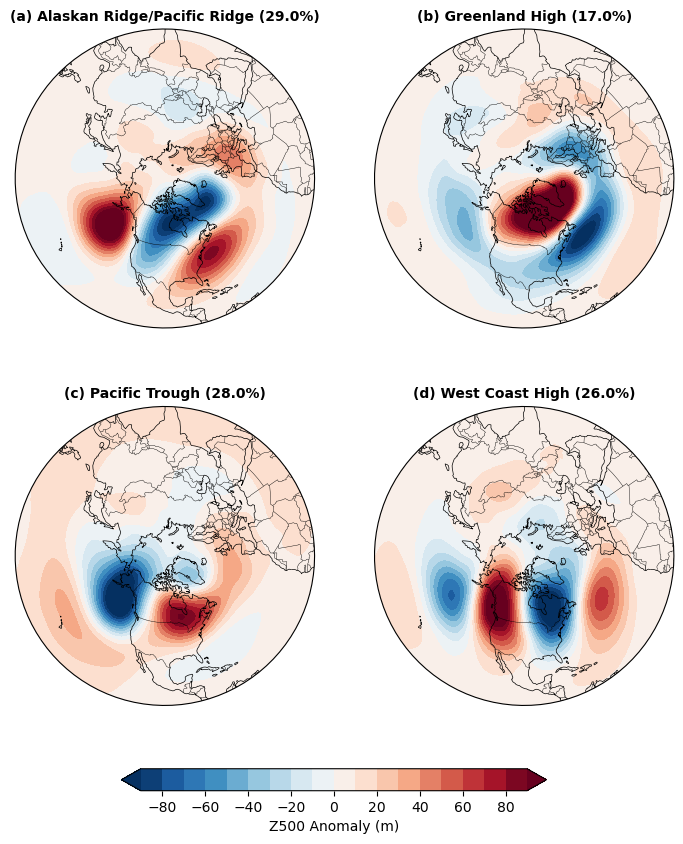

In [18]:
plot_cluster_composites(ds_comp, cmap='RdBu_r', lon_0=260,
                        suptitle=None, 
                        nrows=2, ncols=2, 
                        levels=np.arange(-90, 100, 10),
                        dpi=300,
                        save_path="../figs/Figure3.png")

## Figure 4
Weather regime precipitation anomaly composites by state

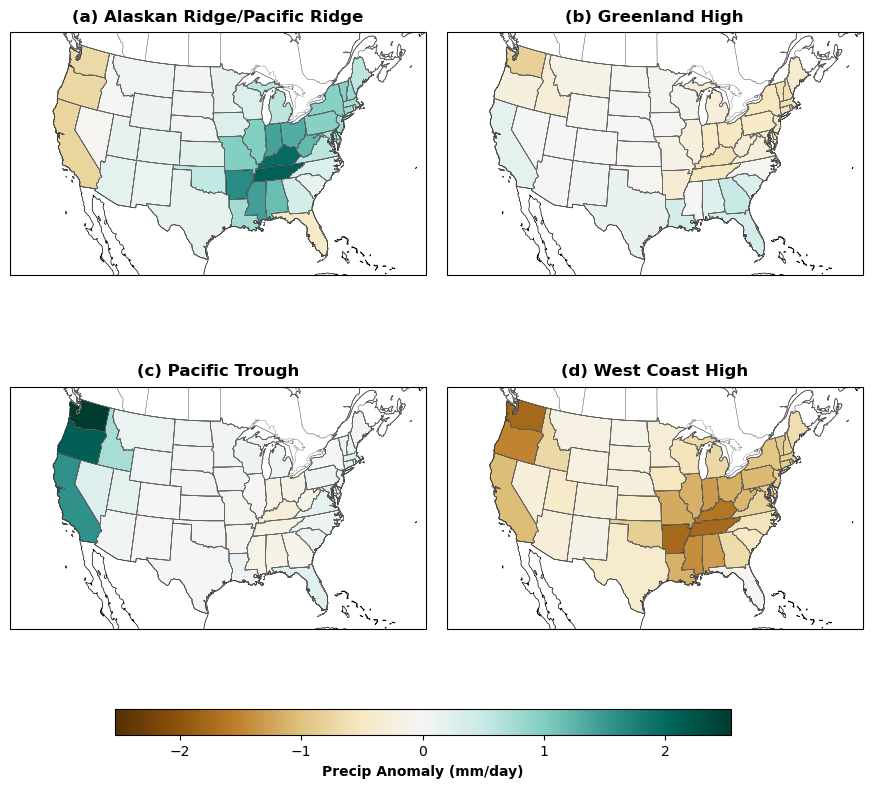

In [19]:
plot_wxregimes_state_precip(df_daily_state,state_centers=state_centers,save_path='../figs/Figure4.png')

In [20]:
df_djf.columns

Index(['STATE_ABBR', 'DATE', 'FATAL_CRASH_COUNT', 'PRECIP_ANOM', 'NINO34_SST',
       'NINO34_PRECIP_ANOM', 'CLUSTER_NAME', 'CLIM_CRASH', 'FATAL_CRASH_ANOM',
       'FATAL_CRASH_ANOM_TREND', 'FATAL_CRASH_ANOM_DETREND'],
      dtype='object')

Quadrant counts (thresholded):
Q1 (+precip, +crash): 1162
Q2 (-precip, +crash): 832
Q3 (-precip, -crash): 1819
Q4 (+precip, -crash): 790
Linear regression (all DJF points):
  slope      = 2.1705
  intercept  = 0.0444
  r          = 0.381
  R^2        = 0.145
  p-value    = 5.492e-213


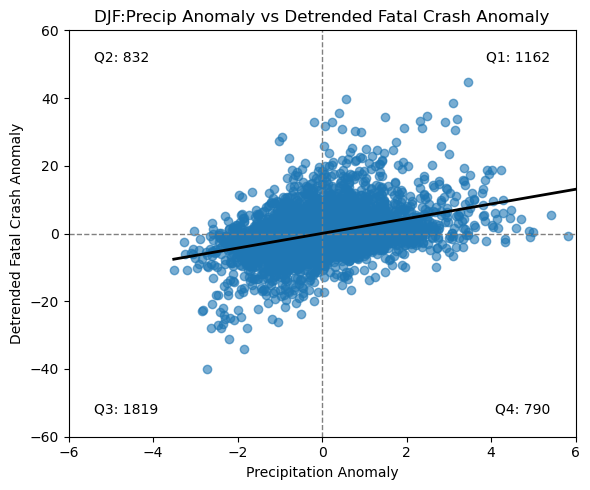

In [21]:
plt.figure(figsize=(6, 5))
plt.scatter(
    df_djf['PRECIP_ANOM'],
    df_djf['FATAL_CRASH_ANOM_DETREND'],
    alpha=0.6
)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.axvline(0, color='gray', linewidth=1, linestyle='--')


# Apply thresholds
df_q = df_djf[
    (df_djf['FATAL_CRASH_ANOM_DETREND'].abs() >= 1.0) &
    (df_djf['PRECIP_ANOM'].abs() >= 0.01)
].copy()
q1 = ((df_q['PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q2 = ((df_q['PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q3 = ((df_q['PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()
q4 = ((df_q['PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()

print("Quadrant counts (thresholded):")
print(f"Q1 (+precip, +crash): {q1}")
print(f"Q2 (-precip, +crash): {q2}")
print(f"Q3 (-precip, -crash): {q3}")
print(f"Q4 (+precip, -crash): {q4}")

# Quadrant count annotations
plt.text( 0.05,  0.95, f"Q2: {q2}", transform=plt.gca().transAxes, ha='left',  va='top')
plt.text( 0.05,  0.05, f"Q3: {q3}", transform=plt.gca().transAxes, ha='left',  va='bottom')
plt.text( 0.95,  0.95, f"Q1: {q1}", transform=plt.gca().transAxes, ha='right', va='top')
plt.text( 0.95,  0.05, f"Q4: {q4}", transform=plt.gca().transAxes, ha='right', va='bottom')


# ---------------- Regression ----------------
x = df_djf['PRECIP_ANOM'].values
y = df_djf['FATAL_CRASH_ANOM_DETREND'].values

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

slope = res.slope
intercept = res.intercept
r = res.rvalue
r2 = r**2
pval = res.pvalue

print("Linear regression (all DJF points):")
print(f"  slope      = {slope:.4f}")
print(f"  intercept  = {intercept:.4f}")
print(f"  r          = {r:.3f}")
print(f"  R^2        = {r2:.3f}")
print(f"  p-value    = {pval:.3e}")

# ---------------- Plot regression line ----------------
xline = np.linspace(x[mask].min(), x[mask].max(), 200)
yline = intercept + slope * xline
plt.plot(xline, yline, color='k', linewidth=2, label=f'Fit: R²={r2:.2f}')
plt.xlim(-6,6)
plt.ylim(-60,60)

plt.xlabel('Precipitation Anomaly')
plt.ylabel('Detrended Fatal Crash Anomaly')
plt.title('DJF:Precip Anomaly vs Detrended Fatal Crash Anomaly')

plt.tight_layout()
plt.show()

Quadrant counts (thresholded):
Q1 (+precip, +crash): 7748
Q2 (-precip, +crash): 4973
Q3 (-precip, -crash): 4694
Q4 (+precip, -crash): 544


Linear regression (all DJF points):
  slope      = 0.0521
  intercept  = 0.0008
  r          = 0.299
  R^2        = 0.090
  p-value    = 0.000e+00


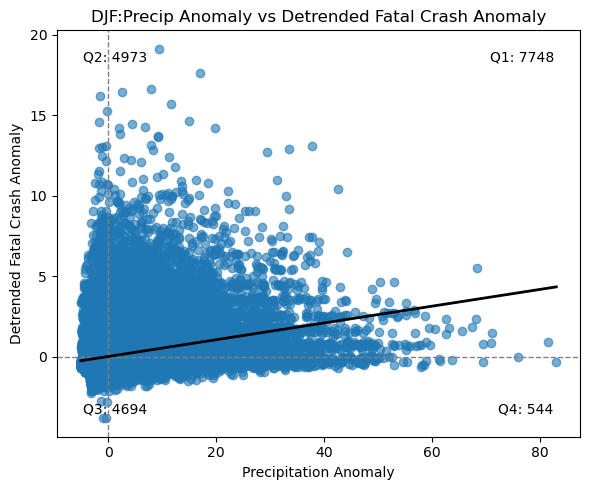

In [22]:
# Select DJF 
df_djf_daily = df_daily_state[df_daily_state['DATE'].dt.month.isin(months_list)]


plt.figure(figsize=(6, 5))
plt.scatter(
    df_djf_daily['PRECIP_ANOM'],
    df_djf_daily['FATAL_CRASH_ANOM_DETREND'],
    alpha=0.6
)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.axvline(0, color='gray', linewidth=1, linestyle='--')


# Apply thresholds
df_q = df_djf_daily[
    (df_djf_daily['FATAL_CRASH_ANOM_DETREND'].abs() >= 1.0) &
    (df_djf_daily['PRECIP_ANOM'].abs() >= 0.01)
].copy()
q1 = ((df_q['PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q2 = ((df_q['PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q3 = ((df_q['PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()
q4 = ((df_q['PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()

print("Quadrant counts (thresholded):")
print(f"Q1 (+precip, +crash): {q1}")
print(f"Q2 (-precip, +crash): {q2}")
print(f"Q3 (-precip, -crash): {q3}")
print(f"Q4 (+precip, -crash): {q4}")

# Quadrant count annotations
plt.text( 0.05,  0.95, f"Q2: {q2}", transform=plt.gca().transAxes, ha='left',  va='top')
plt.text( 0.05,  0.05, f"Q3: {q3}", transform=plt.gca().transAxes, ha='left',  va='bottom')
plt.text( 0.95,  0.95, f"Q1: {q1}", transform=plt.gca().transAxes, ha='right', va='top')
plt.text( 0.95,  0.05, f"Q4: {q4}", transform=plt.gca().transAxes, ha='right', va='bottom')


# ---------------- Regression ----------------
x = df_djf_daily['PRECIP_ANOM'].values
y = df_djf_daily['FATAL_CRASH_ANOM_DETREND'].values

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

slope = res.slope
intercept = res.intercept
r = res.rvalue
r2 = r**2
pval = res.pvalue

print("Linear regression (all DJF points):")
print(f"  slope      = {slope:.4f}")
print(f"  intercept  = {intercept:.4f}")
print(f"  r          = {r:.3f}")
print(f"  R^2        = {r2:.3f}")
print(f"  p-value    = {pval:.3e}")

# ---------------- Plot regression line ----------------
xline = np.linspace(x[mask].min(), x[mask].max(), 200)
yline = intercept + slope * xline
plt.plot(xline, yline, color='k', linewidth=2, label=f'Fit: R²={r2:.2f}')
#plt.xlim(-6,6)
#plt.ylim(-60,60)

plt.xlabel('Precipitation Anomaly')
plt.ylabel('Detrended Fatal Crash Anomaly')
plt.title('DJF:Precip Anomaly vs Detrended Fatal Crash Anomaly')

plt.tight_layout()
plt.show()

Quadrant counts (thresholded):
Q1 (+precip, +crash): 702
Q2 (-precip, +crash): 1047
Q3 (-precip, -crash): 1533
Q4 (+precip, -crash): 739


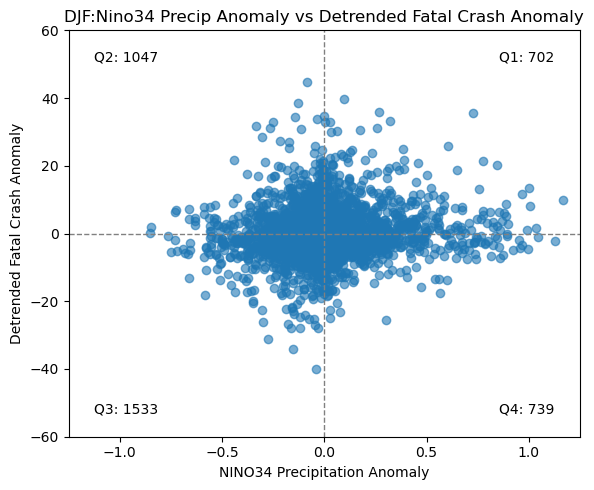

In [23]:
plt.figure(figsize=(6, 5))
plt.scatter(
    df_djf['NINO34_PRECIP_ANOM'],
    df_djf['FATAL_CRASH_ANOM_DETREND'],
    alpha=0.6
)

plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.axvline(0, color='gray', linewidth=1, linestyle='--')


# Apply thresholds
df_q = df_djf[
    (df_djf['FATAL_CRASH_ANOM_DETREND'].abs() >= 1.0) &
    (df_djf['NINO34_PRECIP_ANOM'].abs() >= 0.01)
].copy()
q1 = ((df_q['NINO34_PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q2 = ((df_q['NINO34_PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0)).sum()
q3 = ((df_q['NINO34_PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()
q4 = ((df_q['NINO34_PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0)).sum()

print("Quadrant counts (thresholded):")
print(f"Q1 (+precip, +crash): {q1}")
print(f"Q2 (-precip, +crash): {q2}")
print(f"Q3 (-precip, -crash): {q3}")
print(f"Q4 (+precip, -crash): {q4}")

# Quadrant count annotations
plt.text( 0.05,  0.95, f"Q2: {q2}", transform=plt.gca().transAxes, ha='left',  va='top')
plt.text( 0.05,  0.05, f"Q3: {q3}", transform=plt.gca().transAxes, ha='left',  va='bottom')
plt.text( 0.95,  0.95, f"Q1: {q1}", transform=plt.gca().transAxes, ha='right', va='top')
plt.text( 0.95,  0.05, f"Q4: {q4}", transform=plt.gca().transAxes, ha='right', va='bottom')

plt.xlim(-1.25,1.25)
plt.ylim(-60,60)
plt.xlabel('NINO34 Precipitation Anomaly')
plt.ylabel('Detrended Fatal Crash Anomaly')
plt.title('DJF:Nino34 Precip Anomaly vs Detrended Fatal Crash Anomaly')

plt.tight_layout()
plt.show()

In [24]:
conditions = [
    (df_q['NINO34_PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0),
    (df_q['NINO34_PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] > 0),
    (df_q['NINO34_PRECIP_ANOM'] < 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0),
    (df_q['NINO34_PRECIP_ANOM'] > 0) & (df_q['FATAL_CRASH_ANOM_DETREND'] < 0),
]

choices = ['Q1', 'Q2', 'Q3', 'Q4']

df_q['quadrant'] = np.select(conditions, choices, default='NA')

quadrant_counts = (
    df_q[df_q['quadrant'] != 'NA']
    .groupby(['STATE_ABBR', 'quadrant'])
    .size()
    .reset_index(name='count')
)

quadrant_counts_wide = (
    quadrant_counts
    .pivot(index='STATE_ABBR', columns='quadrant', values='count')
    .fillna(0)
    .astype(int)
)

quadrant_counts_wide

quadrant,Q1,Q2,Q3,Q4
STATE_ABBR,,,,
AL,28,20,33,24
AR,23,20,37,25
AZ,27,18,39,13
CA,21,30,42,26
CO,13,23,30,19
CT,15,24,23,21
DE,14,9,20,20
FL,28,19,46,23
GA,29,20,42,20


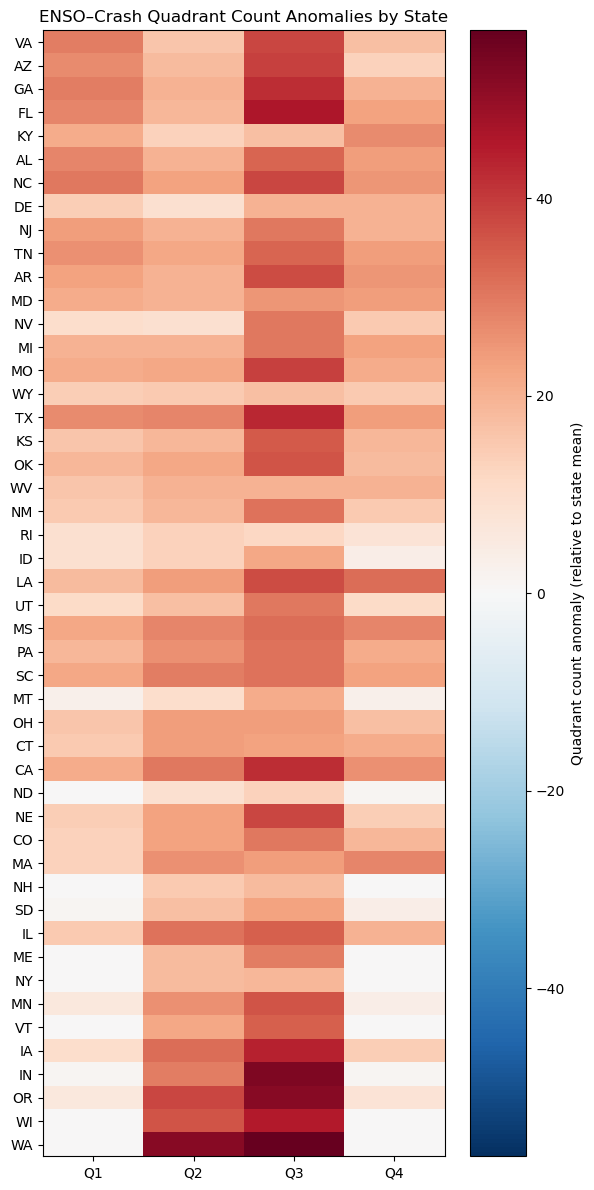

In [25]:
df = quadrant_counts_wide.copy()

# Expected count per quadrant per state
expected = df.sum(axis=1) / 4.0

# Subtract expected from each quadrant
df_anom = df #.sub(expected, axis=0)

order = (df_anom['Q1'] - df_anom['Q2']).sort_values(ascending=False).index
df_anom = df_anom.loc[order]

vmax = np.abs(df_anom.values).max()

fig, ax = plt.subplots(figsize=(6, 12))

im = ax.imshow(
    df_anom.values,
    aspect='auto',
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax
)

# Axes
ax.set_xticks(np.arange(df_anom.shape[1]))
ax.set_yticks(np.arange(df_anom.shape[0]))
ax.set_xticklabels(df_anom.columns)
ax.set_yticklabels(df_anom.index)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Quadrant count anomaly (relative to state mean)')

ax.set_title('ENSO–Crash Quadrant Count Anomalies by State')

plt.tight_layout()
plt.show()

ax.axvline(1.5, color='k', linewidth=1)

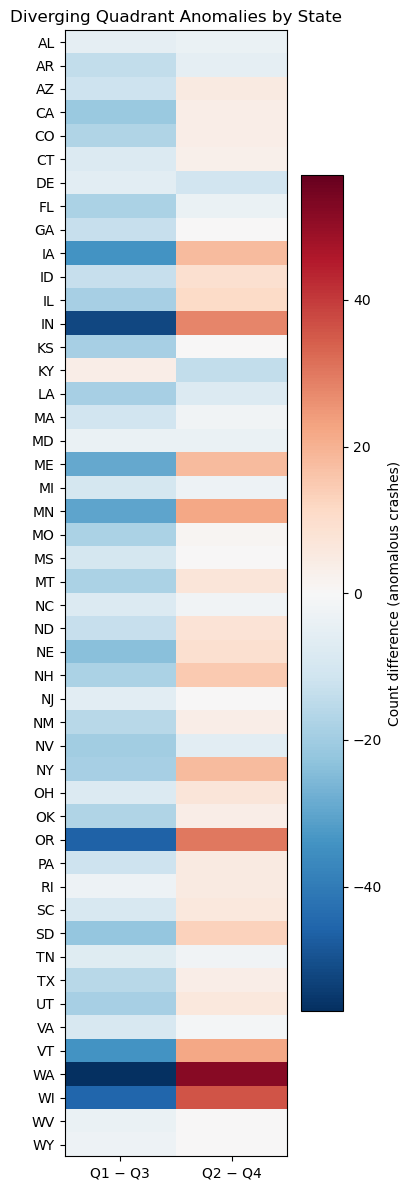

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make sure your quadrant_counts_wide exists and looks like:
# index: STATE_ABBR
# columns: ['Q1','Q2','Q3','Q4']

df = quadrant_counts_wide.copy()

# Compute diverging contrasts
df['Q1_minus_Q3'] = df['Q1'] - df['Q3']
df['Q2_minus_Q4'] = df['Q2'] - df['Q4']

# Prepare for plotting: two-column heatmap
plot_data = df[['Q1_minus_Q3', 'Q2_minus_Q4']]

# Figure setup
fig, ax = plt.subplots(figsize=(4, 12))

# Diverging colormap, symmetric around zero
vmax = np.max(np.abs(plot_data.values))
im = ax.imshow(plot_data.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

# Axis labels
ax.set_yticks(np.arange(len(plot_data)))
ax.set_yticklabels(plot_data.index)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Q1 − Q3', 'Q2 − Q4'])

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count difference (anomalous crashes)')

# Title
ax.set_title('Diverging Quadrant Anomalies by State')

plt.tight_layout()
plt.show()


# Figure 8
R-squared for precip and enso precip

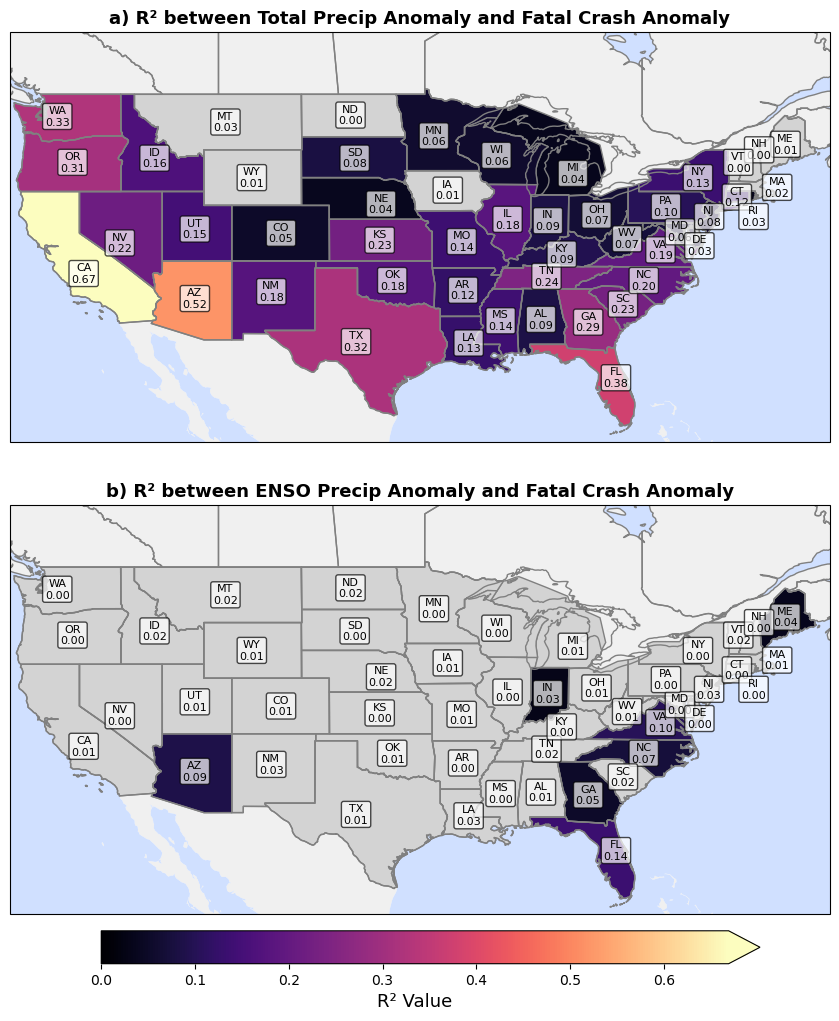

In [27]:
r2_all = compute_state_precip_r2(df_djf, 
                                         crash_col='FATAL_CRASH_ANOM_DETREND', 
                                         precip_col='PRECIP_ANOM')
r2_enso = compute_state_precip_r2(df_djf, 
                                         crash_col='FATAL_CRASH_ANOM_DETREND', 
                                         precip_col='NINO34_PRECIP_ANOM')

plot_r2_map_panels([r2_all,r2_enso], state_centers, save_path='../figs/Figure8.png')

# Figure 9
R-squared for daily precip and enso daily precip

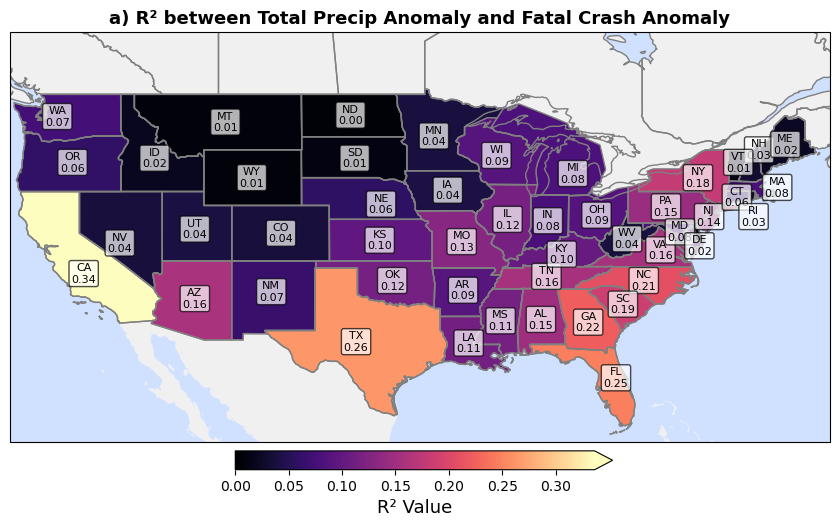

In [28]:
r2_all_daily = compute_state_precip_r2(df_djf_daily,
                                       crash_col='FATAL_CRASH_ANOM_DETREND',
                                       precip_col='PRECIP_ANOM')

plot_r2_map_panels([r2_all_daily], state_centers, save_path='../figs/Figure9.png')

## Figure 10: CONUS Crashes per day by Weather Regime

In [29]:
# Select DJF from Daily State Data
df_djf_daily = df_daily_national[df_daily_national['DATE'].dt.month.isin(months_list)]

=== Summary statistics per regime ===
Alaskan Ridge/Pacific Ridge: n=1004, mean=2.543, std=11.409, skew=0.911, kurtosis=0.902, CV bw=3.084
Greenland High: n=611, mean=0.903, std=10.657, skew=0.971, kurtosis=0.995, CV bw=2.489
Pacific Trough: n=995, mean=-0.386, std=10.689, skew=1.107, kurtosis=1.559, CV bw=2.009
West Coast High: n=909, mean=-1.967, std=10.112, skew=1.470, kurtosis=3.478, CV bw=3.821
All Regimes: n=3880, mean=-0.027, std=10.702, skew=1.108, kurtosis=1.614, CV bw=2.489


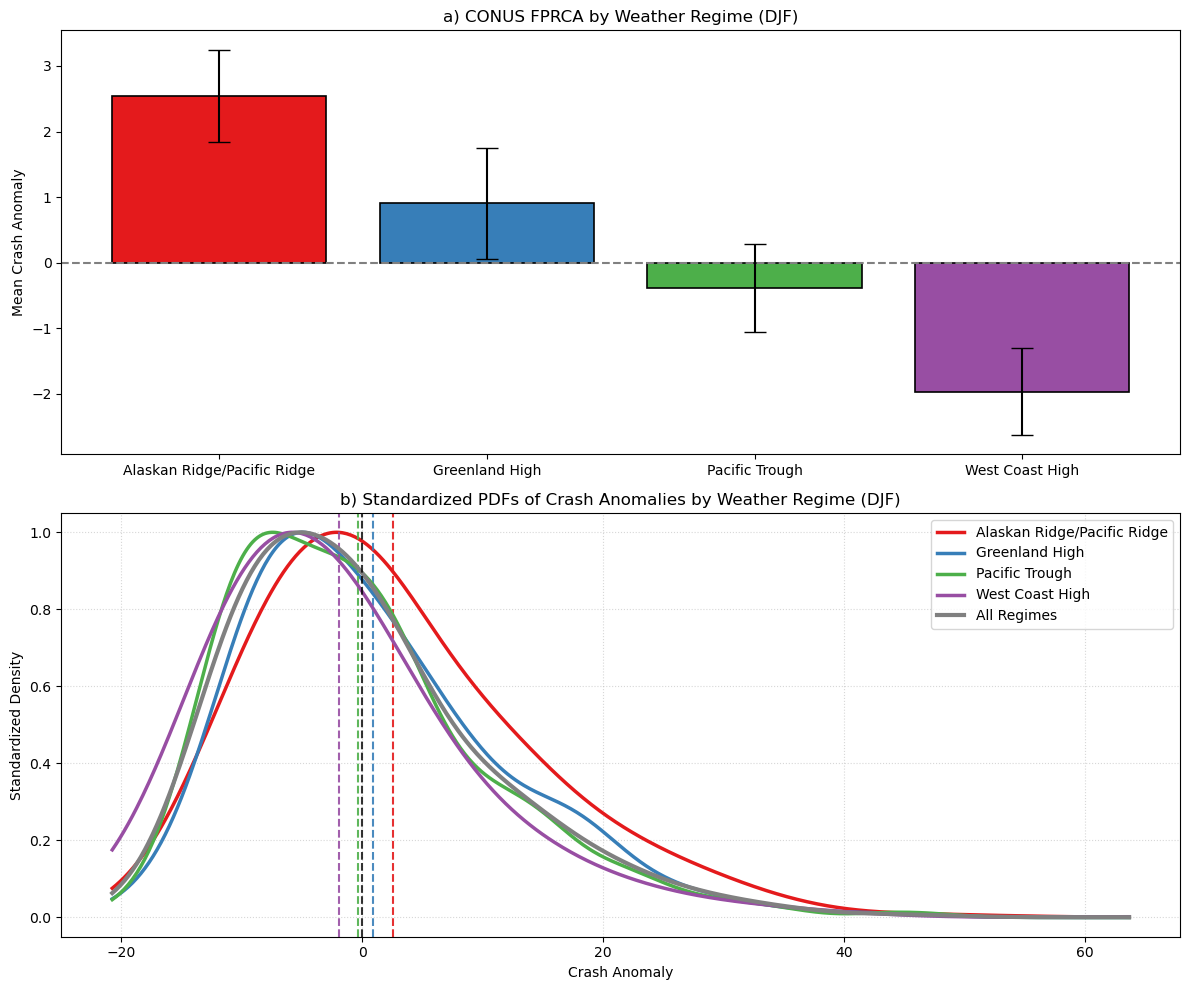

In [30]:
plot_crash_anomalies_cv_smooth(
    df_djf_daily,
    cluster_col='CLUSTER_NAME',
    anomaly_col='FATAL_CRASH_ANOM',
    output_file='../figs/Figure10.png',
    smooth_factor=1.5  # increase to make curves smoother
)

# Figure 11 State Crashes by Weather Regimes

In [31]:
df_djf_daily_state = df_daily_state[df_daily_state['DATE'].dt.month.isin(months_list)]

df_avg = (
    df_djf_daily_state.groupby(["STATE_ABBR", "CLUSTER_NAME"])["FATAL_CRASH_ANOM_DETREND"]
    .mean()
    .reset_index()
)

print(df_avg)

    STATE_ABBR                 CLUSTER_NAME  FATAL_CRASH_ANOM_DETREND
0           AL  Alaskan Ridge/Pacific Ridge                  0.112905
1           AL               Greenland High                  0.002002
2           AL               Pacific Trough                 -0.037677
3           AL              West Coast High                 -0.097879
4           AR  Alaskan Ridge/Pacific Ridge                  0.075704
..         ...                          ...                       ...
187         WV              West Coast High                  0.032079
188         WY  Alaskan Ridge/Pacific Ridge                  0.004797
189         WY               Greenland High                  0.013347
190         WY               Pacific Trough                  0.002879
191         WY              West Coast High                 -0.014196

[192 rows x 3 columns]


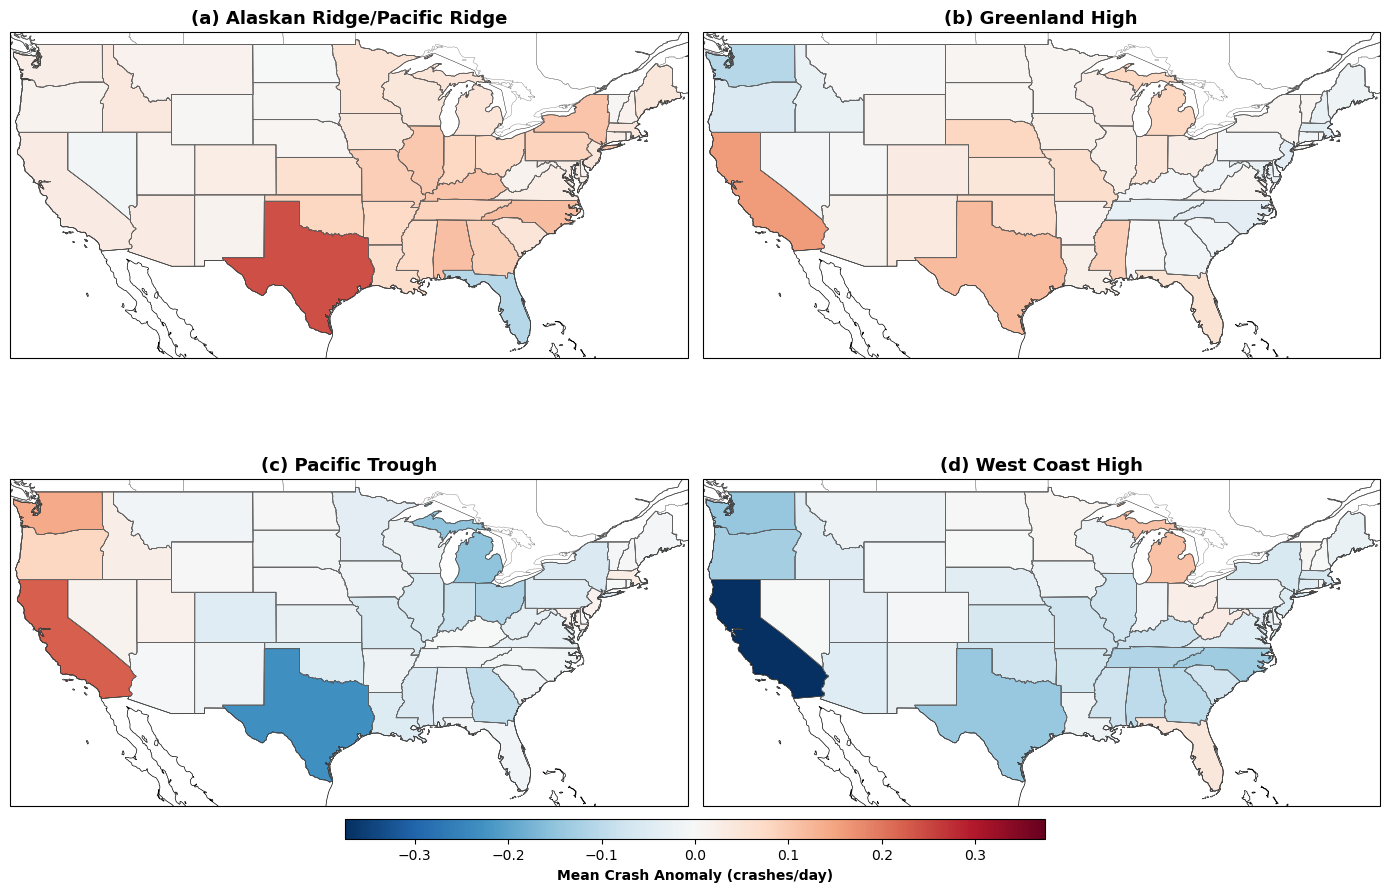

In [32]:
plot_wxregimes_state_crash_anomalies_2x2(df_avg,state_centers=state_centers,save_path='../figs/Figure11.png')

In [33]:
# Figure 11 state pdfs

# Select DJF months
df_djf_monthly = df_monthly_state[df_monthly_state['DATE'].dt.month.isin(months_list)]

# States to analyze
states = ['TX', 'CA', 'WA']

# Define colors for regimes
pdf_colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3'] 

# x-grid for KDEs
x_grid = np.linspace(df_djf_monthly['FATAL_CRASH_ANOM'].min(),
                     df_djf_monthly['FATAL_CRASH_ANOM'].max(), 500)

for state in states:
    df_state = df_djf_monthly[df_djf_monthly['STATE_ABBR'] == state]
    regimes = sorted(df_state['CLUSTER_NAME'].dropna().unique())
    
    plt.figure(figsize=(10, 6))
    
    # Store data for KS tests
    data_dict = {}
    
    for i, reg in enumerate(regimes):
        data = df_state[df_state['CLUSTER_NAME'] == reg]['FATAL_CRASH_ANOM'].dropna()
        if len(data) < 2:
            continue
        data_dict[reg] = data
        pdf = gaussian_kde(data)(x_grid)
        pdf /= pdf.max()
        plt.plot(x_grid, pdf, color=pdf_colors[i % len(pdf_colors)], linewidth=2, label=reg)
        plt.axvline(data.mean(), color=pdf_colors[i % len(pdf_colors)], linestyle='--', alpha=0.7)

    plt.title(f'{state} – Crash Anomalies by Weather Regime (DJF)')
    plt.xlabel('Crash Anomaly')
    plt.ylabel('Standardized Density')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Quantify differences using KS test
    print(f"\nKolmogorov–Smirnov test results for {state}:")
    pairs = [(r1, r2) for i, r1 in enumerate(regimes) for r2 in regimes[i+1:]]
    for r1, r2 in pairs:
        if r1 in data_dict and r2 in data_dict:
            stat, pval = ks_2samp(data_dict[r1], data_dict[r2])
            print(f"  {r1} vs {r2}: D={stat:.3f}, p={pval:.4f}")

plot_state_crash_pdfs_cv_all(df_monthly_state,
                             months_list=months_list,
                             states=['TX','CA','WA'],
                             smooth_factor=1.5)